In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2025-01-15 17:51:03.690586


#### Functions

#### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'

str_dirname_output = './output'

Project: 20241112-simple-model-test
Task: ad_hoc


#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [5]:
# import
list_str_filename = [
    'train',
    'valid',
    'test',
    'inform',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/09_60_in_720/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
    )
    # logic
    if str_filename == 'valid':
        df['data_set'] = 'train'
    else:
        pass
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# save memory
del list_df
# show
df

100%|██████████| 5/5 [00:06<00:00,  1.38s/it]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,request_month,train,valid,test,inform,holdout,data_set
175,5716209,2021-07-30 13:53:28.0444771,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Washington,Franchise,Washington,True,...,0,0,0,2021-07-01,1,0,0,0,0,train
154,5702150,2021-07-30 10:22:57.8246513,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Indiana,Franchise,Indiana,True,...,0,0,1,2021-07-01,1,0,0,0,0,train
18,5702106,2021-07-27 12:40:50.0115498,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,0,0,0,2021-07-01,1,0,0,0,0,train
207,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Illinois,Franchise,Illinois,False,...,1,1,0,2021-07-01,1,0,0,0,0,train
206,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,False,...,1,1,0,2021-07-01,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40317,6408804,2022-11-08 01:11:23+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-07.gzip,1,1,Alabama,Franchise,Alabama,False,...,0,0,0,2022-11-01,0,0,0,0,1,holdout
41049,6404526,2022-11-19 01:39:13+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-18.gzip,1,1,Utah,Independent,Louisiana,False,...,1,1,1,2022-11-01,0,0,0,0,1,holdout
40102,6409395,2022-11-03 22:28:01+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-03.gzip,1,1,Washington,Franchise,Washington,False,...,0,0,0,2022-11-01,0,0,0,0,1,holdout
41352,6408000,2022-11-24 03:33:54+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-23.gzip,1,1,Maryland,Franchise,Maryland,True,...,0,0,0,2022-11-01,0,0,0,0,1,holdout


#### BK Bad Rate by Data Set

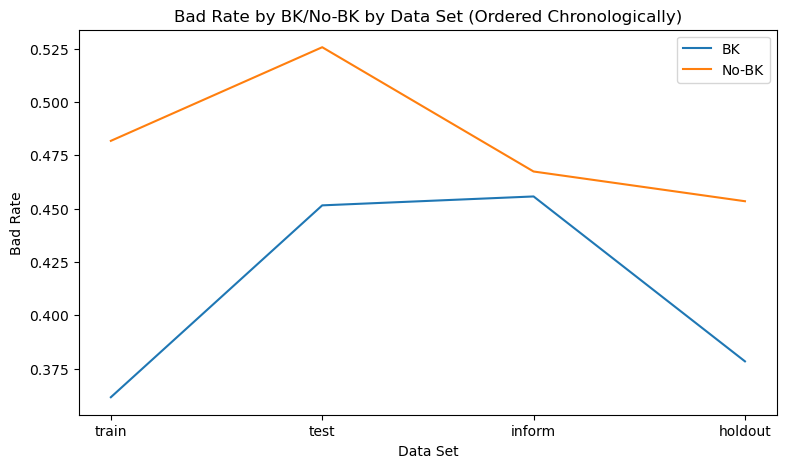

In [6]:
list_cols = [
    'data_set',
    'ENG-bk',
]
df_tmp = df.groupby(by=list_cols, as_index=False).agg({
    str_target: 'mean',
})
# bk
df_bk = df_tmp[df_tmp['ENG-bk'] == 1].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'BK',
}
df_bk.rename(columns=dict_rename, inplace=True)
df_bk.drop('ENG-bk', axis=1, inplace=True)
# nobk
df_nobk = df_tmp[df_tmp['ENG-bk'] == 0].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'No-BK',
}
df_nobk.rename(columns=dict_rename, inplace=True)
df_nobk.drop('ENG-bk', axis=1, inplace=True)
# join
df_tmp = pd.merge(
    left=df_bk,
    right=df_nobk,
    on='data_set',
    how='left',
)
# sort
dict_sort = {
    'train': 1,
    'test': 2,
    'inform': 3,
    'holdout': 4,
}
df_tmp['order'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by='order', ascending=True, inplace=True)
df_tmp.drop('order', axis=1, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by BK/No-BK by Data Set (Ordered Chronologically)')
ax.set_ylabel('Bad Rate')
ax.set_xlabel('Data Set')
ax.plot(df_tmp['data_set'], df_tmp['BK'], label='BK')
ax.plot(df_tmp['data_set'], df_tmp['No-BK'], label='No-BK')
# legend
ax.legend()
# show
plt.show()

#### BK Bad Rate by Month

/tmp/ipykernel_25375/872229834.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_tmp['request_month'], rotation=90)


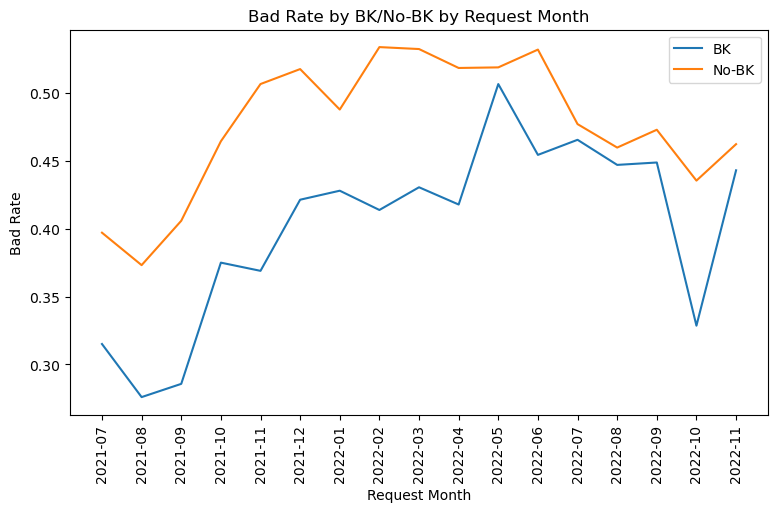

In [7]:
df['request_month'] = df['request_datetime'].apply(
    lambda x: str(x)[:7]
)

list_cols = [
    'request_month',
    'ENG-bk',
]
df_tmp = df.groupby(by=list_cols, as_index=False).agg({
    str_target: 'mean',
})
# bk
df_bk = df_tmp[df_tmp['ENG-bk'] == 1].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'BK',
}
df_bk.rename(columns=dict_rename, inplace=True)
df_bk.drop('ENG-bk', axis=1, inplace=True)
# nobk
df_nobk = df_tmp[df_tmp['ENG-bk'] == 0].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'No-BK',
}
df_nobk.rename(columns=dict_rename, inplace=True)
df_nobk.drop('ENG-bk', axis=1, inplace=True)
# join
df_tmp = pd.merge(
    left=df_bk,
    right=df_nobk,
    on='request_month',
    how='left',
)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by BK/No-BK by Request Month')
ax.set_ylabel('Bad Rate')
ax.set_xlabel('Request Month')
ax.plot(df_tmp['request_month'], df_tmp['BK'], label='BK')
ax.plot(df_tmp['request_month'], df_tmp['No-BK'], label='No-BK')
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
# legend
ax.legend()
# show
plt.show()

#### Franchise Bad Rate by Data Set

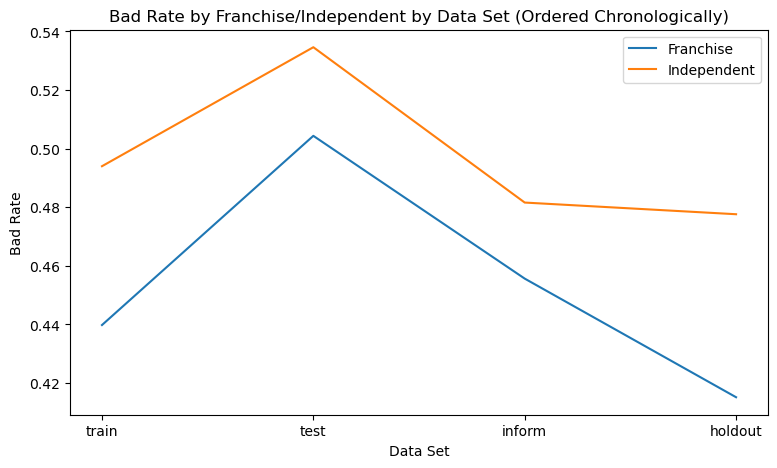

In [8]:
list_cols = [
    'data_set',
    'ENG-franchise',
]
df_tmp = df.groupby(by=list_cols, as_index=False).agg({
    str_target: 'mean',
})
# bk
df_bk = df_tmp[df_tmp['ENG-franchise'] == 1].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'Franchise',
}
df_bk.rename(columns=dict_rename, inplace=True)
df_bk.drop('ENG-franchise', axis=1, inplace=True)
# nobk
df_nobk = df_tmp[df_tmp['ENG-franchise'] == 0].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'Independent',
}
df_nobk.rename(columns=dict_rename, inplace=True)
df_nobk.drop('ENG-franchise', axis=1, inplace=True)
# join
df_tmp = pd.merge(
    left=df_bk,
    right=df_nobk,
    on='data_set',
    how='left',
)
# sort
dict_sort = {
    'train': 1,
    'test': 2,
    'inform': 3,
    'holdout': 4,
}
df_tmp['order'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by='order', ascending=True, inplace=True)
df_tmp.drop('order', axis=1, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by Franchise/Independent by Data Set (Ordered Chronologically)')
ax.set_ylabel('Bad Rate')
ax.set_xlabel('Data Set')
ax.plot(df_tmp['data_set'], df_tmp['Franchise'], label='Franchise')
ax.plot(df_tmp['data_set'], df_tmp['Independent'], label='Independent')
# legend
ax.legend()
# show
plt.show()

#### Franchise bad Rate by Month

/tmp/ipykernel_25375/142987643.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_tmp['request_month'], rotation=90)


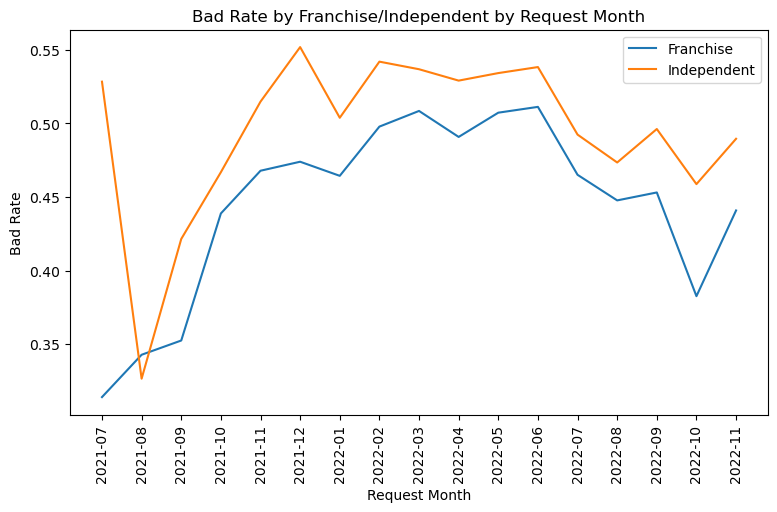

In [9]:
df['request_month'] = df['request_datetime'].apply(
    lambda x: str(x)[:7]
)

list_cols = [
    'request_month',
    'ENG-franchise',
]
df_tmp = df.groupby(by=list_cols, as_index=False).agg({
    str_target: 'mean',
})
# bk
df_bk = df_tmp[df_tmp['ENG-franchise'] == 1].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'Franchise',
}
df_bk.rename(columns=dict_rename, inplace=True)
df_bk.drop('ENG-franchise', axis=1, inplace=True)
# nobk
df_nobk = df_tmp[df_tmp['ENG-franchise'] == 0].copy()
dict_rename = {
    'Early_Pay_Delinquency_60_720_Flag': 'Independent',
}
df_nobk.rename(columns=dict_rename, inplace=True)
df_nobk.drop('ENG-franchise', axis=1, inplace=True)
# join
df_tmp = pd.merge(
    left=df_bk,
    right=df_nobk,
    on='request_month',
    how='left',
)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by Franchise/Independent by Request Month')
ax.set_ylabel('Bad Rate')
ax.set_xlabel('Request Month')
ax.plot(df_tmp['request_month'], df_tmp['Franchise'], label='Franchise')
ax.plot(df_tmp['request_month'], df_tmp['Independent'], label='Independent')
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
# legend
ax.legend()
# show
plt.show()